# Player Classifier — Exploratory Data Analysis
Synthetic dataset: 2004 races, 6 player types (unbalanced), 9 features per race (3-lap aggregate).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RAW_CSV = Path('../../Data/player_classifier/raw/kart_race_data.csv')
df = pd.read_csv(RAW_CSV)
print(df.shape)
df.head()

(2004, 10)


,lapTime_delta,position_delta,mapCollisions_total,shellsUsed_total,bananasUsed_total,mushroomsUsed_total,starsUsed_total,bananaHitsReceived_total,shellHitsReceived_total,player_type
0,33.055,5.1,7,1,2,0,0,2,2,Slow
1,14.325,4.2,5,1,2,2,0,1,0,Conservative
2,17.901,4.1,19,1,3,0,0,7,5,Clumsy
3,7.127,1.0,1,4,1,5,0,2,2,Pro
4,35.926,5.4,5,0,1,2,0,2,2,Slow


## 1. Basic info

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lapTime_delta             2004 non-null   float64
 1   position_delta            2004 non-null   float64
 2   mapCollisions_total       2004 non-null   int64  
 3   shellsUsed_total          2004 non-null   int64  
 4   bananasUsed_total         2004 non-null   int64  
 5   mushroomsUsed_total       2004 non-null   int64  
 6   starsUsed_total           2004 non-null   int64  
 7   bananaHitsReceived_total  2004 non-null   int64  
 8   shellHitsReceived_total   2004 non-null   int64  
 9   player_type               2004 non-null   object 
dtypes: float64(2), int64(7), object(1)
memory usage: 156.7+ KB


In [3]:
df.describe()

,lapTime_delta,position_delta,mapCollisions_total,shellsUsed_total,bananasUsed_total,mushroomsUsed_total,starsUsed_total,bananaHitsReceived_total,shellHitsReceived_total
count,2004.000000,2004.000000,2004.000000,2004.000000,2004.000000,2004.000000,2004.000000,2004.000000,2004.000000
mean,19.349578,3.717166,12.066367,2.067365,1.993014,1.453593,0.011477,3.282934,2.776447
std,8.613585,1.468696,10.815342,1.982437,1.895406,1.318611,0.106541,2.783822,2.176882
min,3.895000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.027750,2.400000,4.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
50%,17.436500,4.000000,8.000000,2.000000,2.000000,1.000000,0.000000,2.000000,2.000000
75%,25.807000,5.000000,18.000000,3.000000,3.000000,2.000000,0.000000,6.000000,5.000000
max,42.819000,6.000000,43.000000,8.000000,8.000000,5.000000,1.000000,10.000000,8.000000


In [4]:
print('Missing values:')
df.isnull().sum()

Missing values:


lapTime_delta               0
position_delta              0
mapCollisions_total         0
shellsUsed_total            0
bananasUsed_total           0
mushroomsUsed_total         0
starsUsed_total             0
bananaHitsReceived_total    0
shellHitsReceived_total     0
player_type                 0
dtype: int64

## 2. Data validation
Verify that the generated data respects the constraints defined in the prompt.

In [5]:
issues = []

# Stars must be 0 or 1, and 0 in at least 95% of rows
stars_above_1 = (df['starsUsed_total'] > 1).sum()
stars_zero_pct = (df['starsUsed_total'] == 0).mean() * 100
if stars_above_1 > 0:
    issues.append(f'starsUsed_total > 1 in {stars_above_1} rows (should be 0)')
if stars_zero_pct < 95:
    issues.append(f'starsUsed_total is 0 in only {stars_zero_pct:.1f}% of rows (need >= 95%)')

# lapTime_delta must be >= 7
bad_laptime = (df['lapTime_delta'] < 7).sum()
if bad_laptime > 0:
    issues.append(f'lapTime_delta < 7s in {bad_laptime} rows')

# position_delta must be between 1.0 and 6.0
bad_pos = ((df['position_delta'] < 1) | (df['position_delta'] > 6)).sum()
if bad_pos > 0:
    issues.append(f'position_delta out of [1,6] in {bad_pos} rows')

# Total powerups must not exceed 12
df['_total_powerups'] = df[['shellsUsed_total','bananasUsed_total','mushroomsUsed_total','starsUsed_total']].sum(axis=1)
bad_powerups = (df['_total_powerups'] > 12).sum()
if bad_powerups > 0:
    issues.append(f'Total powerups > 12 in {bad_powerups} rows')
df.drop(columns=['_total_powerups'], inplace=True)

# lapTime and position must correlate positively
corr_time_pos = df['lapTime_delta'].corr(df['position_delta'])
if corr_time_pos < 0.5:
    issues.append(f'lapTime_delta vs position_delta correlation is {corr_time_pos:.2f} (expected > 0.5)')

# lapTime and mapCollisions must correlate positively
corr_time_col = df['lapTime_delta'].corr(df['mapCollisions_total'])
if corr_time_col < 0:
    issues.append(f'lapTime_delta vs mapCollisions correlation is {corr_time_col:.2f} (expected > 0)')

print(f'Stars distribution:\n{df["starsUsed_total"].value_counts().sort_index()}')
print(f'Stars zero rate: {stars_zero_pct:.1f}%')
print(f'lapTime-position correlation: {corr_time_pos:.3f}')
print(f'lapTime-collisions correlation: {corr_time_col:.3f}')
print()
if issues:
    print('ISSUES FOUND:')
    for i in issues:
        print(f'  ✗ {i}')
else:
    print('✓ All validation checks passed')

Stars distribution:
starsUsed_total
0    1981
1      23
Name: count, dtype: int64
Stars zero rate: 98.9%
lapTime-position correlation: 0.877
lapTime-collisions correlation: 0.238

ISSUES FOUND:
  ✗ lapTime_delta < 7s in 2 rows


## 3. Class balance

              count   pct
player_type              
Slow            501  25.0
Conservative    441  22.0
Clumsy          401  20.0
Aggressive      301  15.0
Chaotic         240  12.0
Pro             120   6.0


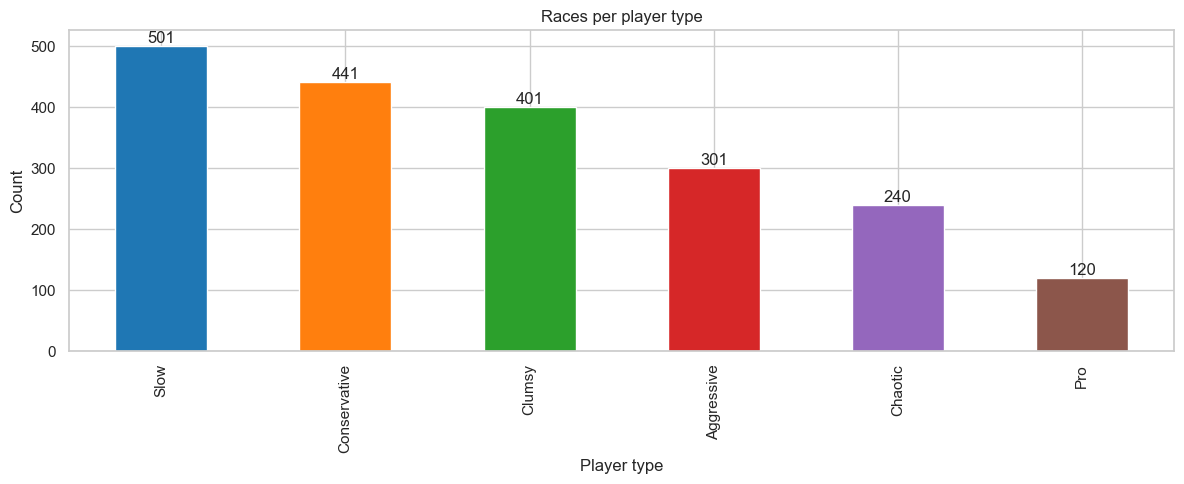

In [6]:
counts = df['player_type'].value_counts()
pcts = (counts / len(df) * 100).round(1)
print(pd.DataFrame({'count': counts, 'pct': pcts}))

ax = counts.plot(kind='bar', color=sns.color_palette('tab10', len(counts)))
ax.set_title('Races per player type')
ax.set_xlabel('Player type')
ax.set_ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 4. Feature distributions per player type

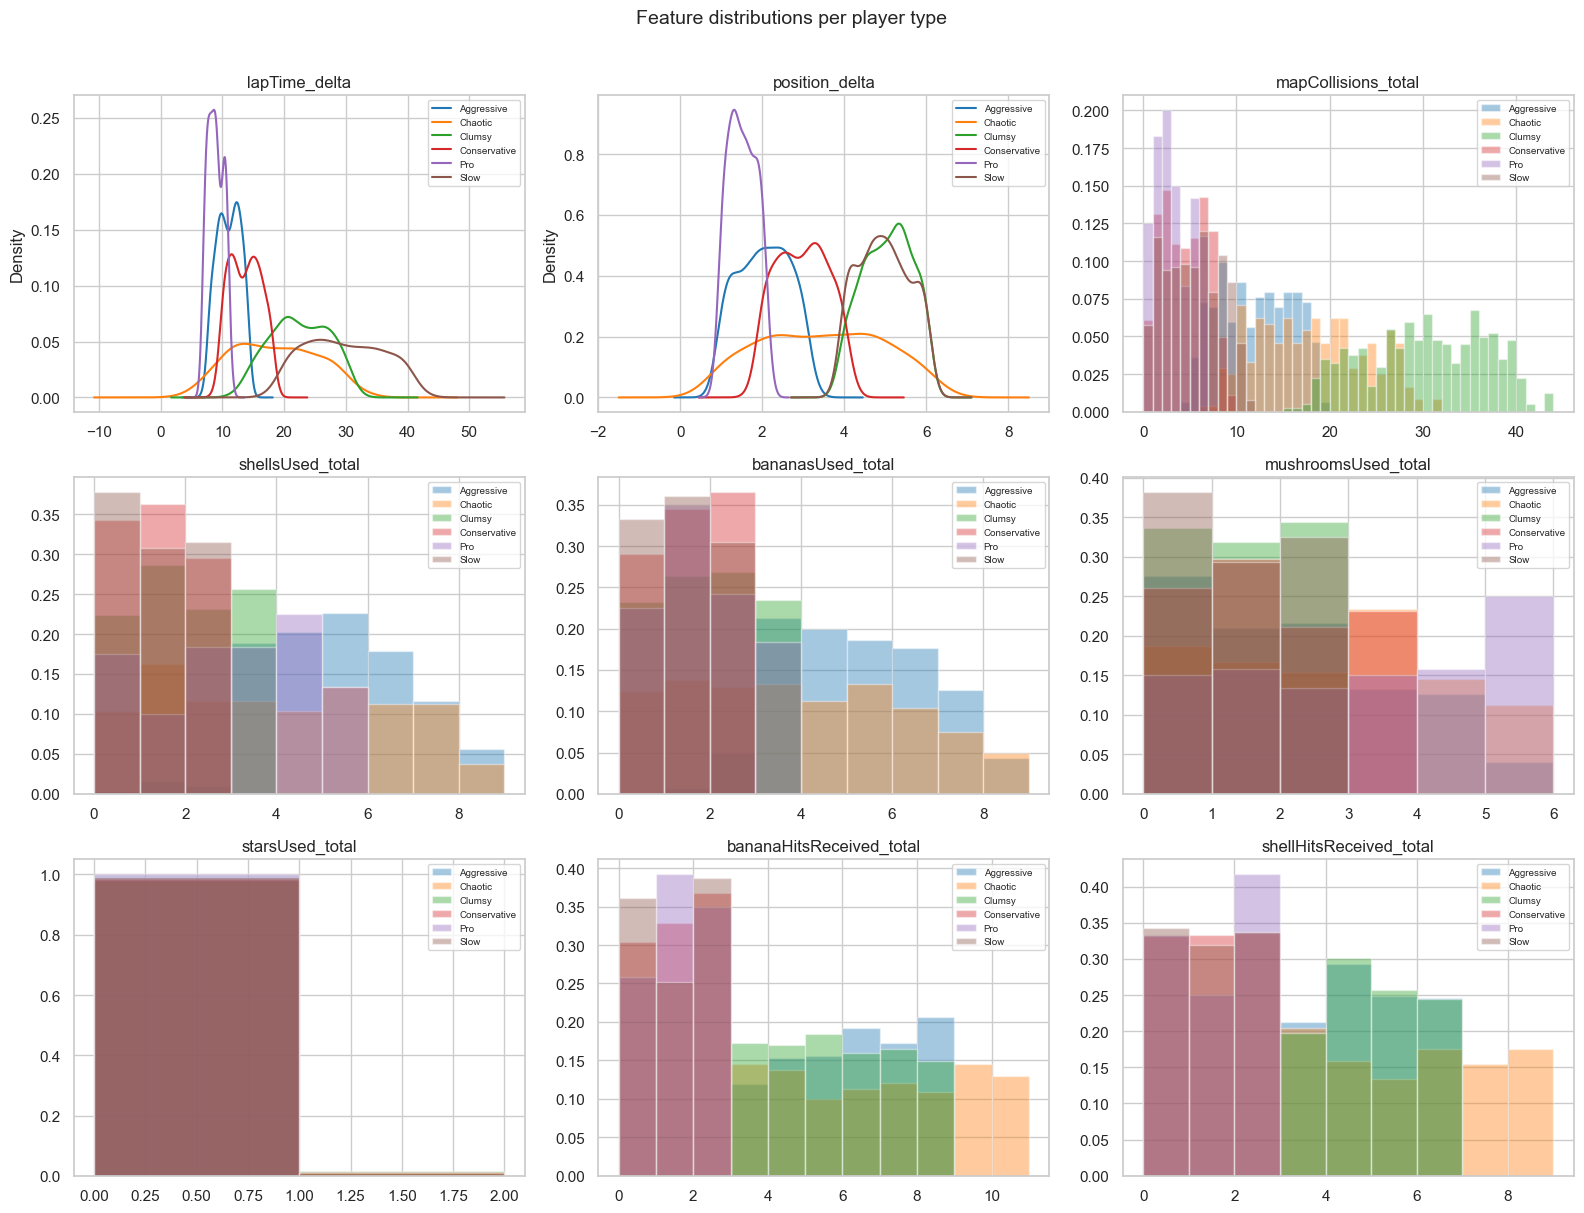

In [7]:
features = [
    'lapTime_delta', 'position_delta', 'mapCollisions_total',
    'shellsUsed_total', 'bananasUsed_total', 'mushroomsUsed_total',
    'starsUsed_total', 'bananaHitsReceived_total', 'shellHitsReceived_total'
]

continuous = ['lapTime_delta', 'position_delta']
integer_feats = [f for f in features if f not in continuous]

player_types = sorted(df['player_type'].unique())
palette = dict(zip(player_types, sns.color_palette('tab10', len(player_types))))

# KDE for continuous, histogram for integers
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, feat in zip(axes.flat, features):
    if feat in continuous:
        for ptype in player_types:
            df[df['player_type'] == ptype][feat].plot(kind='kde', ax=ax, label=ptype, color=palette[ptype])
    else:
        for ptype in player_types:
            subset = df[df['player_type'] == ptype][feat]
            ax.hist(subset, alpha=0.4, label=ptype, color=palette[ptype],
                    bins=range(int(subset.min()), int(subset.max()) + 2), density=True)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Feature distributions per player type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Boxplots — median and spread per class

/var/folders/01/xckckf2s1_5b_mwwmpd2v21r0000gn/T/ipykernel_24360/580907378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_type', y=feat, palette='tab10', ax=ax,
/var/folders/01/xckckf2s1_5b_mwwmpd2v21r0000gn/T/ipykernel_24360/580907378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_type', y=feat, palette='tab10', ax=ax,
/var/folders/01/xckckf2s1_5b_mwwmpd2v21r0000gn/T/ipykernel_24360/580907378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_type', y=feat, palette='tab10',

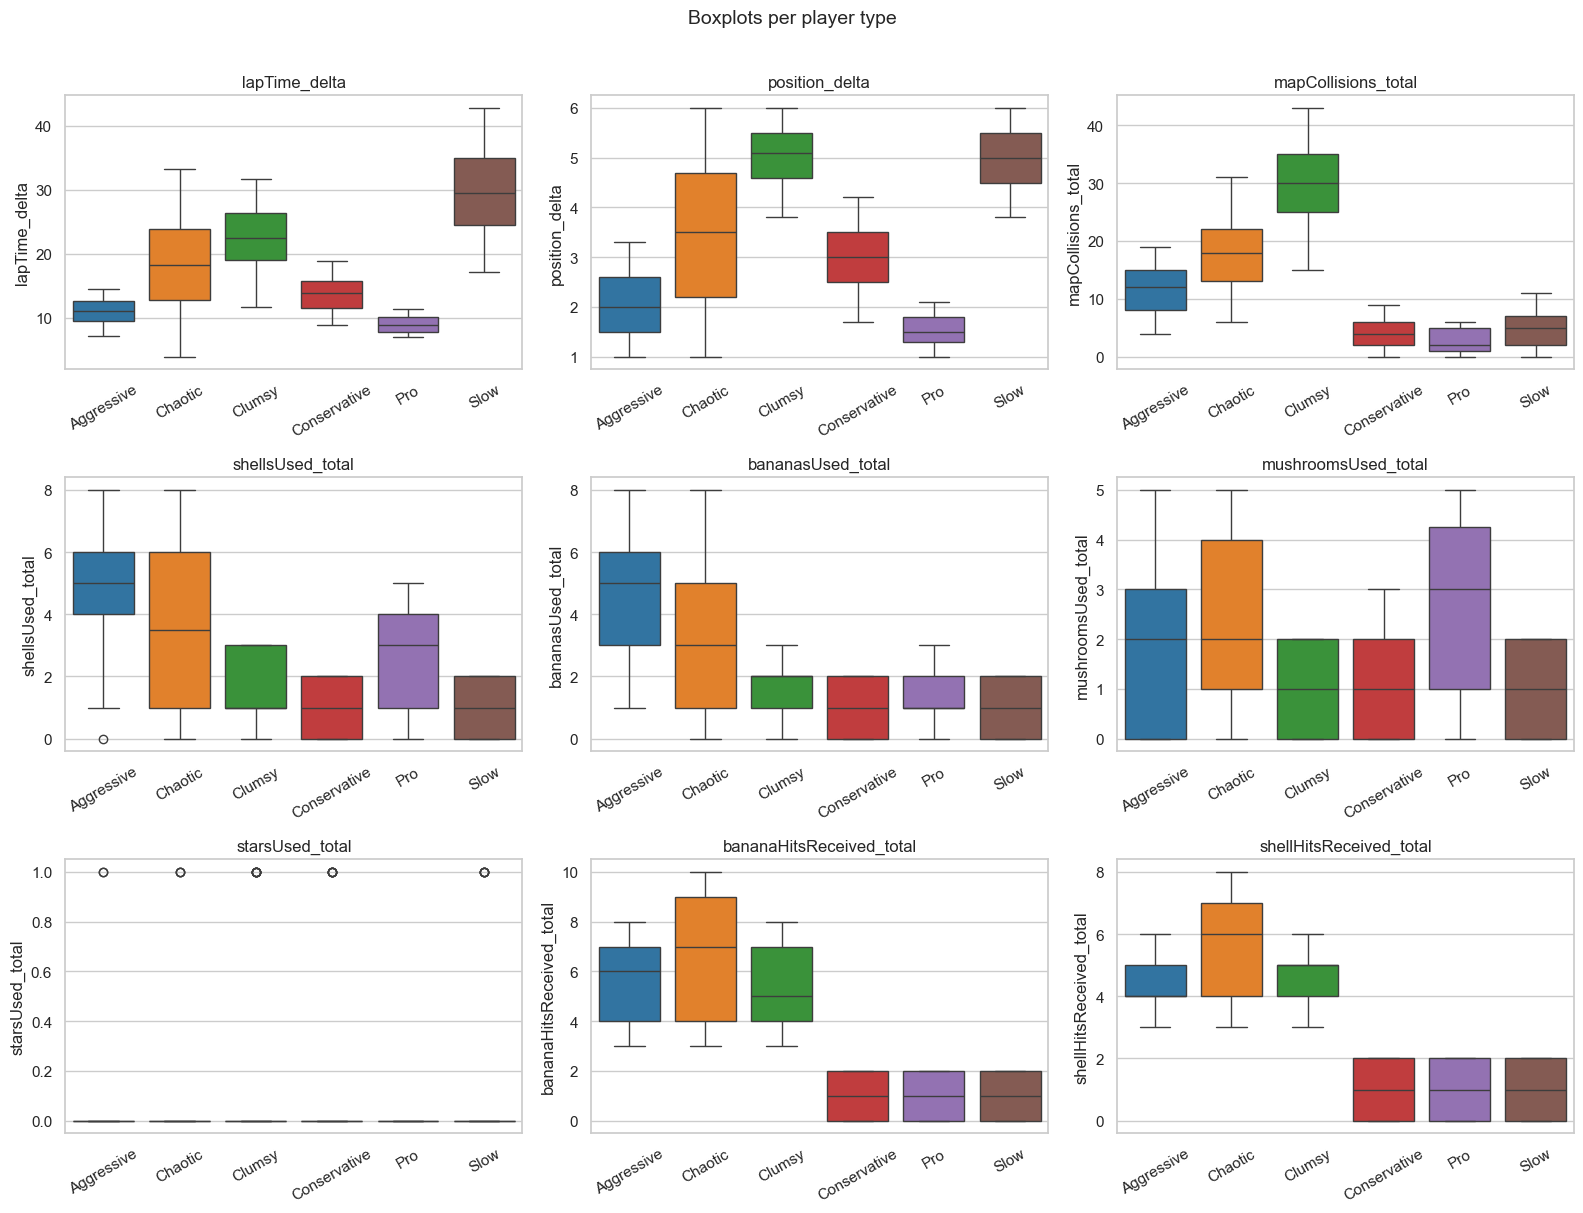

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x='player_type', y=feat, palette='tab10', ax=ax,
                order=player_types)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Boxplots per player type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Mean ± std per class

In [9]:
mean_ = df.groupby('player_type')[features].mean().round(2)
std_  = df.groupby('player_type')[features].std().round(2)

# Build a single readable table: "mean ± std"
summary_str = mean_.astype(str) + ' ± ' + std_.astype(str)
print('Mean ± Std per player type:')
summary_str.T

Mean ± Std per player type:


player_type,Aggressive,Chaotic,Clumsy,Conservative,Pro,Slow
lapTime_delta,11.03 ± 1.83,18.48 ± 6.77,22.46 ± 4.66,13.74 ± 2.47,8.89 ± 1.23,29.72 ± 6.22
position_delta,2.04 ± 0.62,3.45 ± 1.46,5.05 ± 0.59,2.98 ± 0.62,1.52 ± 0.33,4.96 ± 0.62
mapCollisions_total,11.56 ± 3.89,17.73 ± 5.82,29.7 ± 6.46,3.97 ± 2.39,2.78 ± 1.93,4.89 ± 2.97
shellsUsed_total,4.89 ± 1.6,3.59 ± 2.4,1.52 ± 1.1,0.95 ± 0.8,2.58 ± 1.66,0.94 ± 0.83
bananasUsed_total,4.76 ± 1.62,3.46 ± 2.38,1.51 ± 1.09,1.07 ± 0.81,1.38 ± 1.03,0.97 ± 0.8
mushroomsUsed_total,1.74 ± 1.5,2.32 ± 1.63,1.01 ± 0.83,1.41 ± 1.11,2.76 ± 1.8,0.94 ± 0.84
starsUsed_total,0.01 ± 0.08,0.01 ± 0.11,0.02 ± 0.13,0.01 ± 0.12,0.0 ± 0.0,0.01 ± 0.1
bananaHitsReceived_total,5.76 ± 1.67,6.48 ± 2.39,5.42 ± 1.69,1.06 ± 0.82,1.09 ± 0.78,1.03 ± 0.87
shellHitsReceived_total,4.53 ± 1.08,5.44 ± 1.78,4.55 ± 1.06,1.0 ± 0.82,1.08 ± 0.87,0.99 ± 0.83


## 7. Mean feature heatmap (normalized)

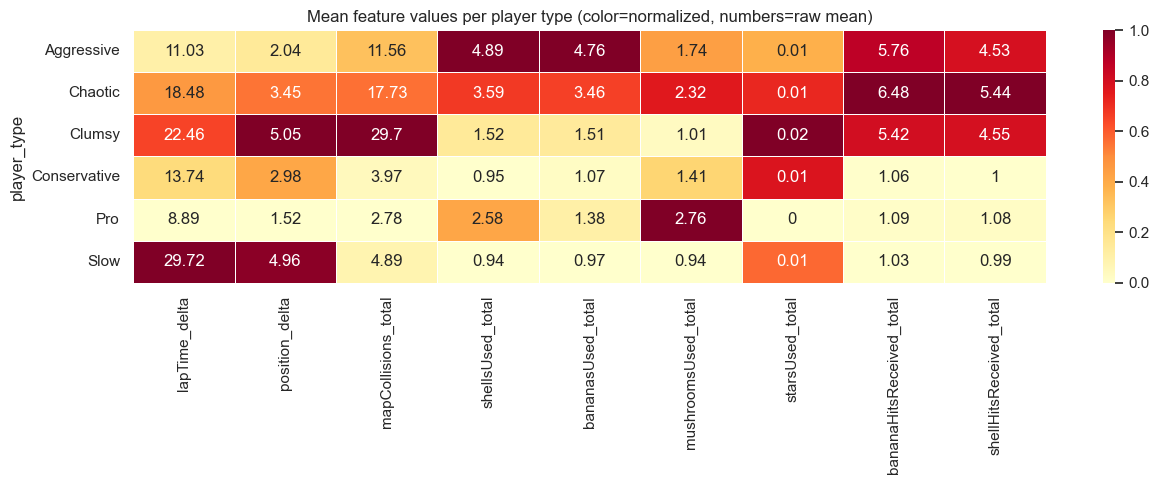

In [10]:
means = df.groupby('player_type')[features].mean()
means_norm = (means - means.min()) / (means.max() - means.min())

plt.figure(figsize=(13, 5))
sns.heatmap(means_norm, annot=means.round(2), fmt='g', cmap='YlOrRd', linewidths=0.5)
plt.title('Mean feature values per player type (color=normalized, numbers=raw mean)')
plt.tight_layout()
plt.show()

## 8. Correlation matrix

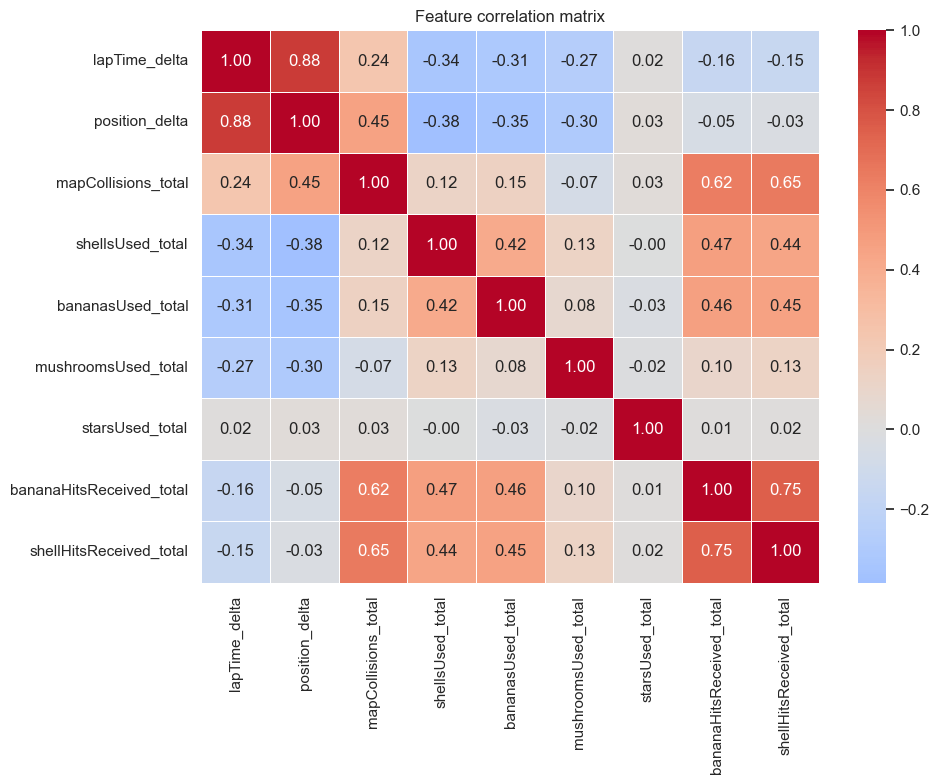

In [11]:
corr = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## 9. Feature engineering

/var/folders/01/xckckf2s1_5b_mwwmpd2v21r0000gn/T/ipykernel_24360/3431528063.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_type', y=feat, palette='tab10', ax=ax,
/var/folders/01/xckckf2s1_5b_mwwmpd2v21r0000gn/T/ipykernel_24360/3431528063.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_type', y=feat, palette='tab10', ax=ax,
/var/folders/01/xckckf2s1_5b_mwwmpd2v21r0000gn/T/ipykernel_24360/3431528063.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='player_type', y=feat, palette='t

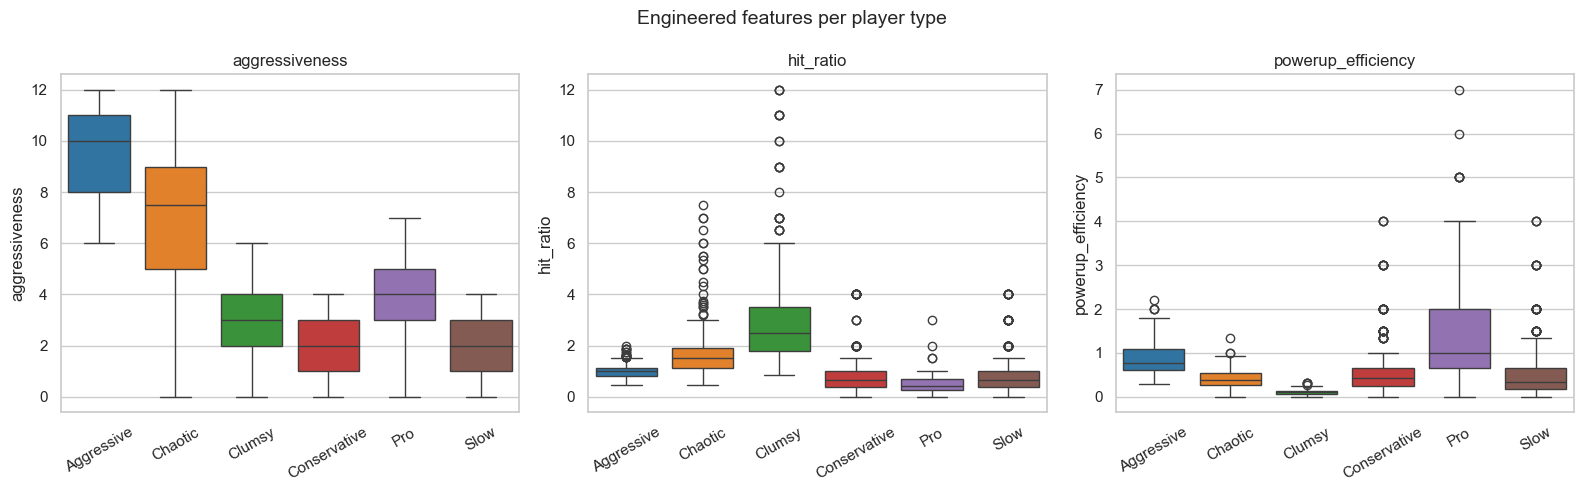

In [12]:
df['aggressiveness'] = df['shellsUsed_total'] + df['bananasUsed_total']

df['hit_ratio'] = (
    (df['bananaHitsReceived_total'] + df['shellHitsReceived_total']) /
    (df['aggressiveness'] + 1)
)

df['powerup_efficiency'] = (
    df['aggressiveness'] /
    (df['mapCollisions_total'] + 1)
)

engineered = ['aggressiveness', 'hit_ratio', 'powerup_efficiency']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, engineered):
    sns.boxplot(data=df, x='player_type', y=feat, palette='tab10', ax=ax,
                order=player_types)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Engineered features per player type', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Feature importance (Random Forest preview)

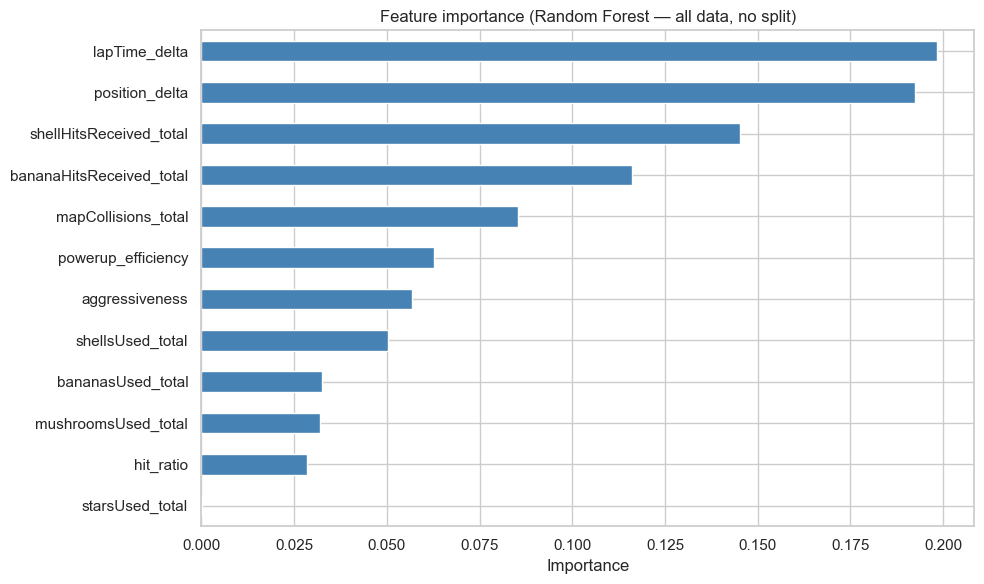

lapTime_delta               0.198414
position_delta              0.192316
shellHitsReceived_total     0.145152
bananaHitsReceived_total    0.116016
mapCollisions_total         0.085262
powerup_efficiency          0.062799
aggressiveness              0.056718
shellsUsed_total            0.050347
bananasUsed_total           0.032539
mushroomsUsed_total         0.031925
hit_ratio                   0.028463
starsUsed_total             0.000050
dtype: float64


In [13]:
all_features = features + engineered
X = df[all_features]
y = LabelEncoder().fit_transform(df['player_type'])

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=True)

ax = importances.plot(kind='barh', figsize=(10, 6), color='steelblue')
ax.set_title('Feature importance (Random Forest — all data, no split)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

## 11. PCA — class separability in 2D

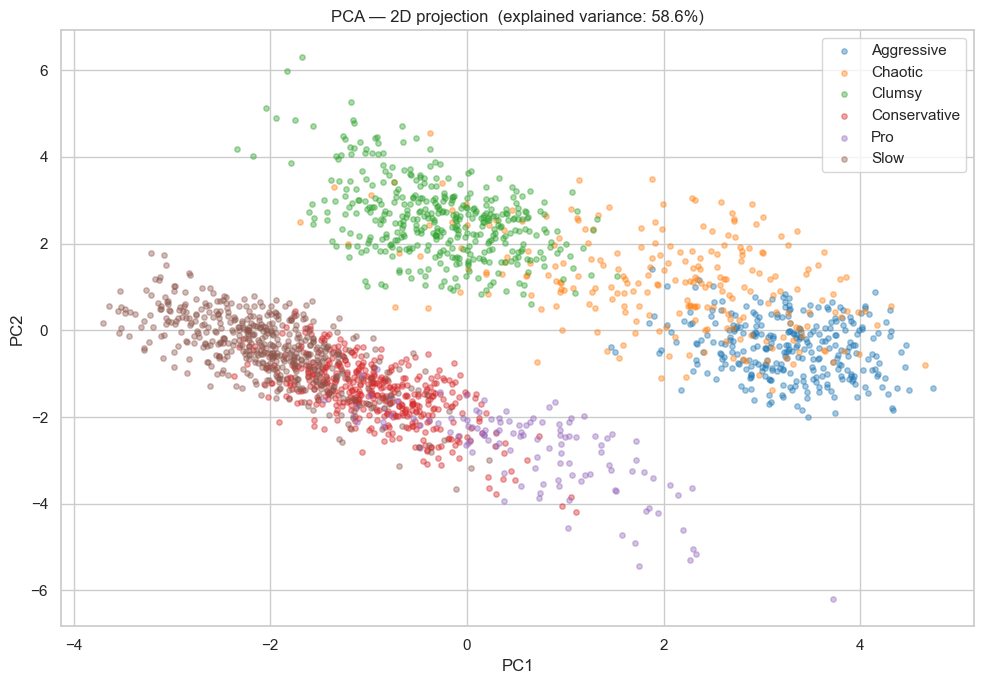

In [14]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df[all_features])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
pca_df['player_type'] = df['player_type'].values

plt.figure(figsize=(10, 7))
for ptype in player_types:
    sub = pca_df[pca_df['player_type'] == ptype]
    plt.scatter(sub['PC1'], sub['PC2'], label=ptype, alpha=0.4, s=15, color=palette[ptype])

plt.legend()
plt.title(f'PCA — 2D projection  (explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## 12. t-SNE — class separability in 2D (non-linear)

/Users/ronald/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


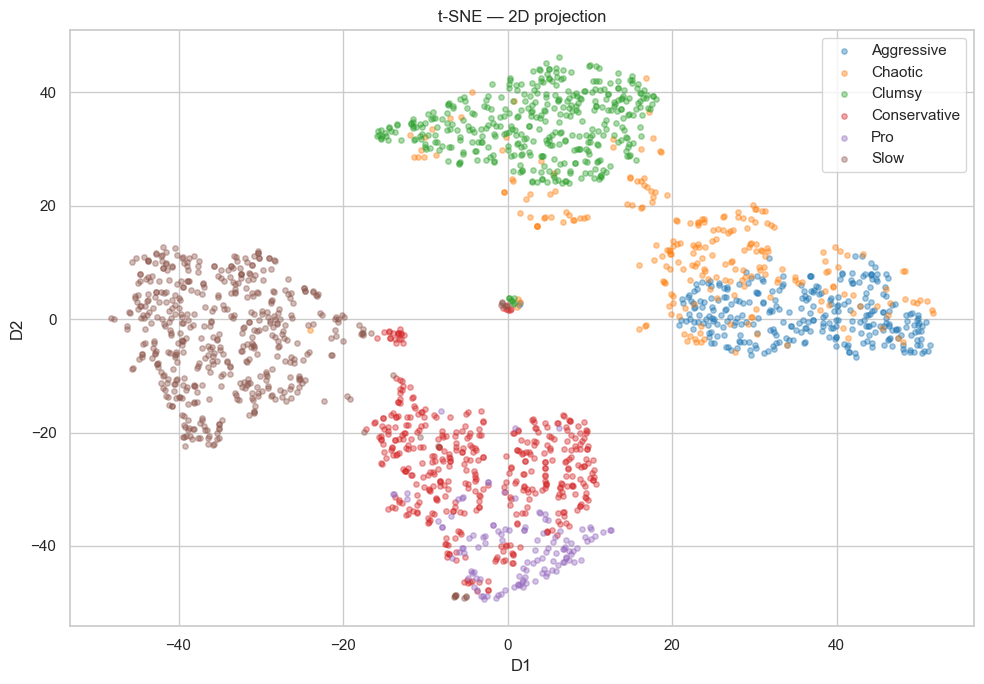

In [15]:
tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1000)
tsne_coords = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(tsne_coords, columns=['D1', 'D2'])
tsne_df['player_type'] = df['player_type'].values

plt.figure(figsize=(10, 7))
for ptype in player_types:
    sub = tsne_df[tsne_df['player_type'] == ptype]
    plt.scatter(sub['D1'], sub['D2'], label=ptype, alpha=0.4, s=15, color=palette[ptype])

plt.legend()
plt.title('t-SNE — 2D projection')
plt.xlabel('D1')
plt.ylabel('D2')
plt.tight_layout()
plt.show()

## 13. Pairplot — most discriminative features

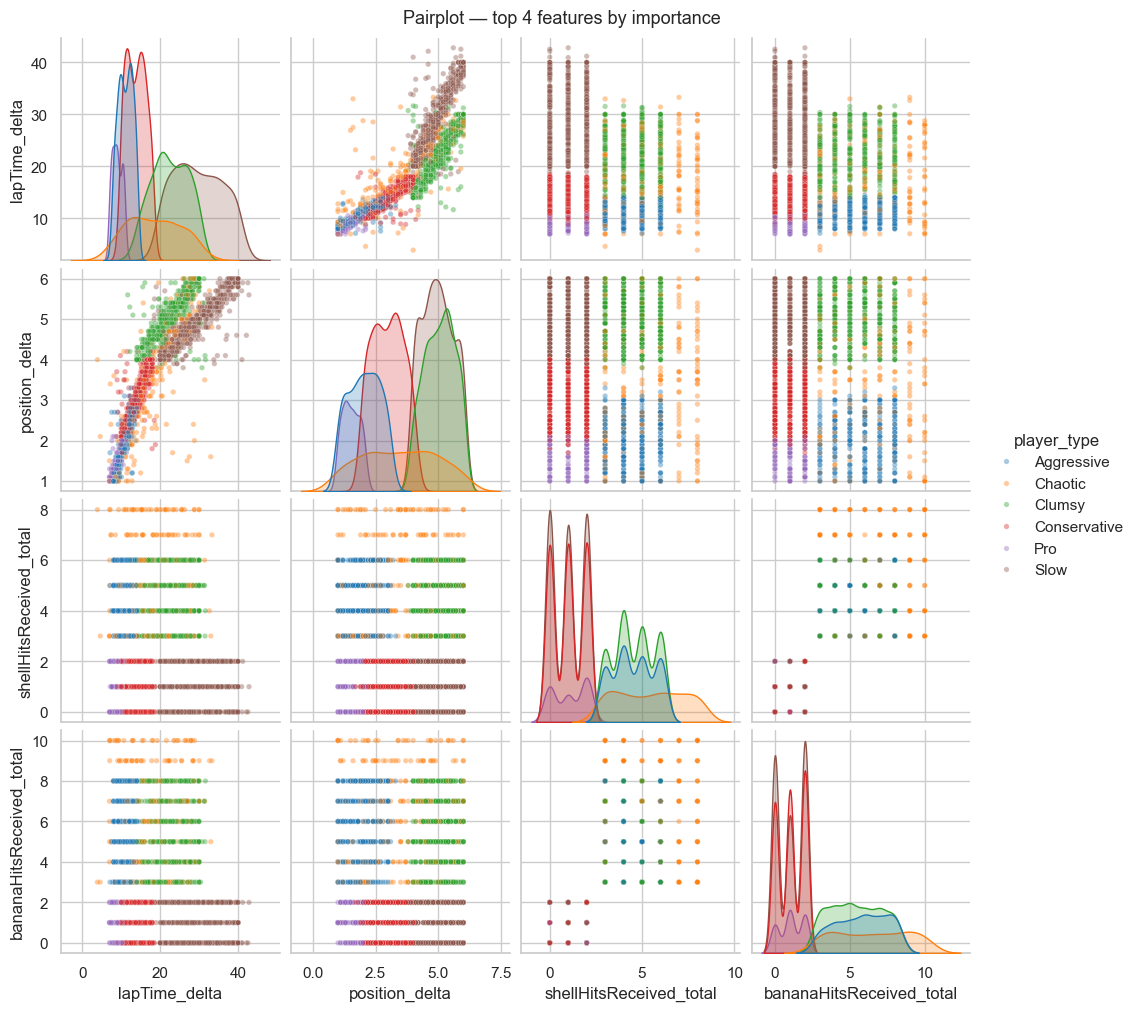

In [16]:
# Use top 4 features by importance + player_type
top4 = importances.sort_values(ascending=False).head(4).index.tolist()
g = sns.pairplot(df[top4 + ['player_type']], hue='player_type', palette='tab10',
                 plot_kws={'alpha': 0.4, 's': 15}, hue_order=player_types)
g.figure.suptitle('Pairplot — top 4 features by importance', y=1.01, fontsize=13)
plt.show()

## 14. Save processed dataset

In [17]:
PROCESSED_CSV = Path('../../Data/player_classifier/processed/kart_race_data_processed.csv')
PROCESSED_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_CSV, index=False)
print(f'Saved to {PROCESSED_CSV}  —  shape: {df.shape}')

Saved to ../../Data/player_classifier/processed/kart_race_data_processed.csv  —  shape: (2004, 13)
